- Nate Diaz-Santana
- Data Presentation & Visualization

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

# Airport Complaint Trends and Operational Insights

## Data Import

In [5]:
airport = pd.read_csv('complaints-by-airport.csv')

In [6]:
airport.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41721 entries, 0 to 41720
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   pdf_report_date  41721 non-null  object
 1   airport          41612 non-null  object
 2   year_month       41721 non-null  object
 3   count            41721 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.3+ MB


In [7]:
airport.head()

,pdf_report_date,airport,year_month,count
0,2019-02,ABE,2015-01,0
1,2019-02,ABE,2015-02,0
2,2019-02,ABE,2015-03,0
3,2019-02,ABE,2015-04,0
4,2019-02,ABE,2015-05,2


In [8]:
category = pd.read_csv('complaints-by-category.csv')

In [9]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241588 entries, 0 to 241587
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   pdf_report_date   241588 non-null  object
 1   airport           237546 non-null  object
 2   category          241588 non-null  object
 3   year_month        241588 non-null  object
 4   count             241588 non-null  int64 
 5   clean_cat         241588 non-null  object
 6   clean_cat_status  241588 non-null  object
dtypes: int64(1), object(6)
memory usage: 12.9+ MB


In [10]:
category.head()

,pdf_report_date,airport,category,year_month,count,clean_cat,clean_cat_status
0,2019-02,ABE,Hazardous Materials Safety,2015-01,0,Hazardous Materials Safety,original
1,2019-02,ABE,Mishandling of Passenger Property,2015-01,0,Mishandling of Passenger Property,original
2,2019-02,ABE,Hazardous Materials Safety,2015-02,0,Hazardous Materials Safety,original
3,2019-02,ABE,Mishandling of Passenger Property,2015-02,0,Mishandling of Passenger Property,original
4,2019-02,ABE,Hazardous Materials Safety,2015-03,0,Hazardous Materials Safety,original


In [11]:
subcategory = pd.read_csv('complaints-by-subcategory.csv')

In [12]:
subcategory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504512 entries, 0 to 504511
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   pdf_report_date             504512 non-null  object
 1   airport                     491048 non-null  object
 2   category                    504512 non-null  object
 3   subcategory                 504512 non-null  object
 4   year_month                  504512 non-null  object
 5   count                       504512 non-null  int64 
 6   clean_cat                   504512 non-null  object
 7   clean_subcat                504512 non-null  object
 8   clean_cat_status            504512 non-null  object
 9   clean_subcat_status         504512 non-null  object
 10  is_category_prefix_removed  504512 non-null  bool  
dtypes: bool(1), int64(1), object(9)
memory usage: 39.0+ MB


In [13]:
subcategory.head()

,pdf_report_date,airport,category,subcategory,year_month,count,clean_cat,clean_subcat,clean_cat_status,clean_subcat_status,is_category_prefix_removed
0,2019-02,ABE,Hazardous Materials Safety,General,2015-01,0,Hazardous Materials Safety,General,original,original,False
1,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-01,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False
2,2019-02,ABE,Hazardous Materials Safety,General,2015-02,0,Hazardous Materials Safety,General,original,original,False
3,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-02,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False
4,2019-02,ABE,Hazardous Materials Safety,General,2015-03,0,Hazardous Materials Safety,General,original,original,False


In [14]:
icao = pd.read_csv('iata-icao.csv')

In [15]:
icao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8937 entries, 0 to 8936
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  8905 non-null   object 
 1   region_name   8937 non-null   object 
 2   iata          8937 non-null   object 
 3   icao          7794 non-null   object 
 4   airport       8937 non-null   object 
 5   latitude      8937 non-null   float64
 6   longitude     8937 non-null   float64
dtypes: float64(2), object(5)
memory usage: 488.9+ KB


In [16]:
icao.head()

,country_code,region_name,iata,icao,airport,latitude,longitude
0,AE,Abu Zaby,AAN,OMAL,Al Ain International Airport,24.2617,55.6092
1,AE,Abu Zaby,AUH,OMAA,Abu Dhabi International Airport,24.4330,54.6511
2,AE,Abu Zaby,AYM,NaN,Yas Island Seaplane Base,24.4670,54.6103
3,AE,Abu Zaby,AZI,OMAD,Al Bateen Executive Airport,24.4283,54.4581
4,AE,Abu Zaby,DHF,OMAM,Al Dhafra Air Base,24.2482,54.5477


## Data Preparation

In [18]:
# datetime formatting
for data in (airport, category, subcategory):
    data['year_month'] = pd.to_datetime(data['year_month'], format='%Y-%m', errors='coerce')
    data['pdf_report_date'] = pd.to_datetime(data['pdf_report_date'], errors='coerce')

In [19]:
# uppercase and no whitespace
airport['airport'] = airport['airport'].astype(str).str.strip().str.upper()
category['airport'] = category['airport'].astype(str).str.strip().str.upper()
subcategory['airport'] = subcategory['airport'].astype(str).str.strip().str.upper()
icao['iata'] = icao['iata'].astype(str).str.strip().str.upper()

In [20]:
# formatting unknowns to NaNs
airport['airport'] = airport['airport'].replace(['NAN', 'nan', 'None', ''], np.nan)
category['airport'] = category['airport'].replace(['NAN', 'nan', 'None', ''], np.nan)
subcategory['airport'] = subcategory['airport'].replace(['NAN', 'nan', 'None', ''], np.nan)

In [21]:
# sum total complaints by airport and time series (for visualizations)
airport_totals = airport.groupby('airport', dropna=True)['count'].sum().reset_index().sort_values('count', ascending=False)
time_series = airport.groupby('year_month')['count'].sum().reset_index().sort_values('year_month')

In [22]:
# coordinate dataset based on airport code matches (for visualizations)
airport_geo = airport_totals.merge(icao[['iata','latitude','longitude','airport']], left_on='airport', right_on='iata', how='left')

## Visualizations

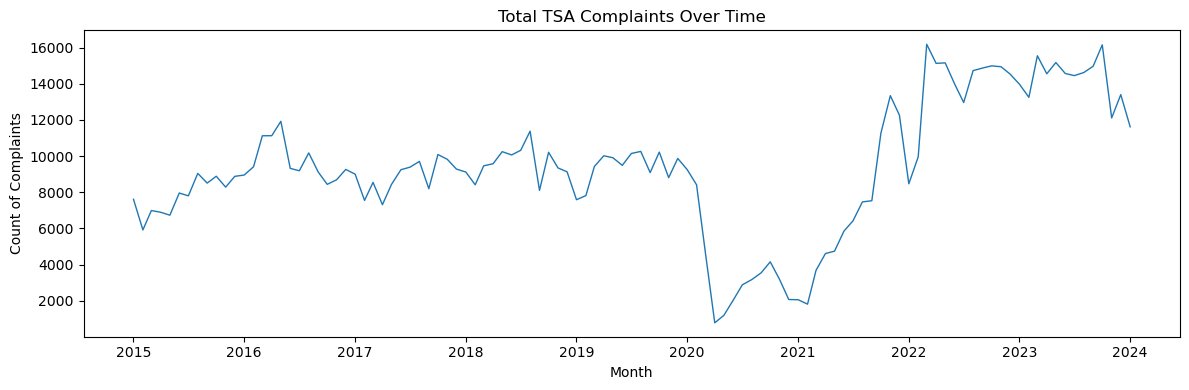

In [24]:
plt.figure(figsize=(12,4))
plt.plot(time_series['year_month'], time_series['count'], linewidth=1)
plt.title('Total TSA Complaints Over Time')
plt.xlabel('Month')
plt.ylabel('Count of Complaints')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

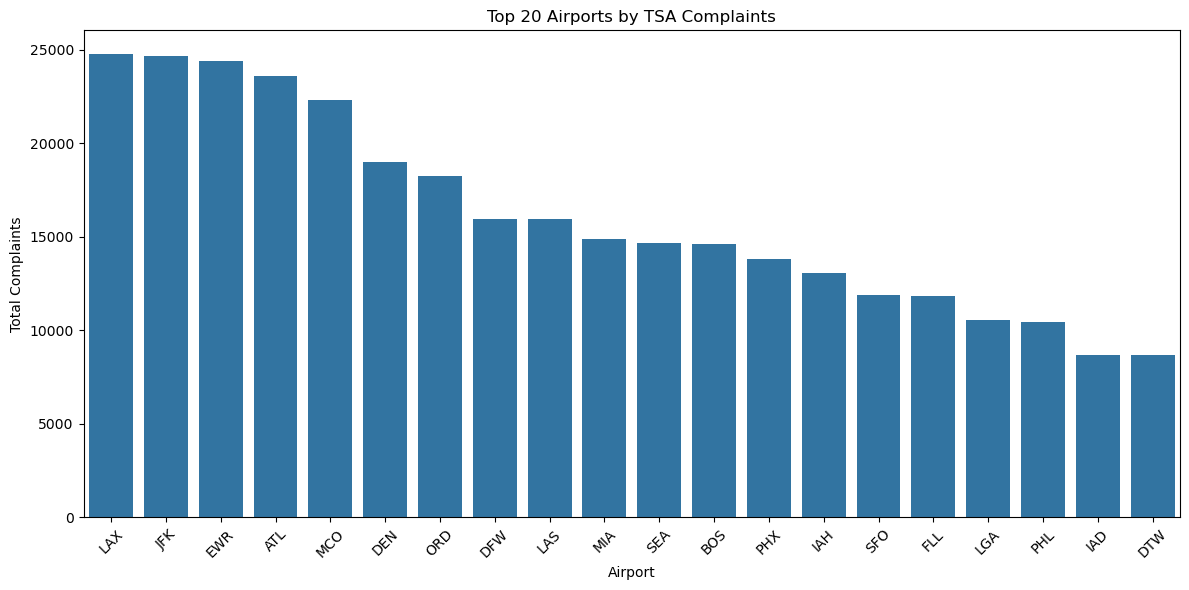

In [25]:
plt.figure(figsize=(12,6))
sb.barplot(data=airport_totals.head(20), x='airport', y='count')
plt.title('Top 20 Airports by TSA Complaints')
plt.xlabel('Airport')
plt.ylabel('Total Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

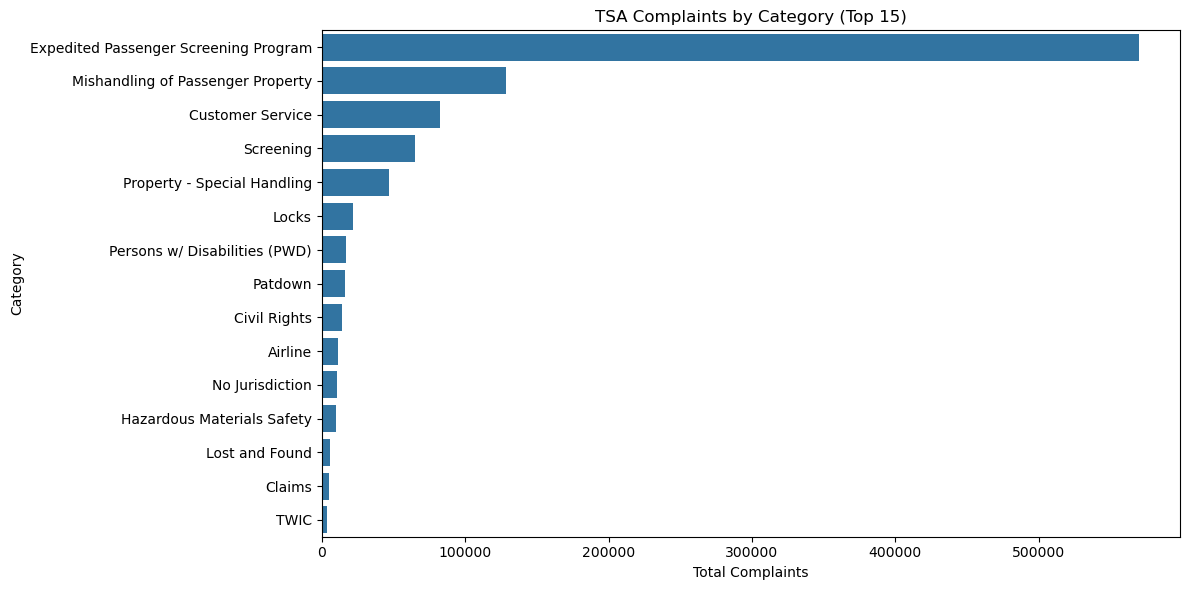

In [26]:
category_totals = category.groupby('clean_cat')['count'].sum().reset_index().sort_values('count', ascending=False).head(15)

plt.figure(figsize=(12,6))
sb.barplot(data=category_totals, x='count', y='clean_cat')
plt.title('TSA Complaints by Category (Top 15)')
plt.xlabel('Total Complaints')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

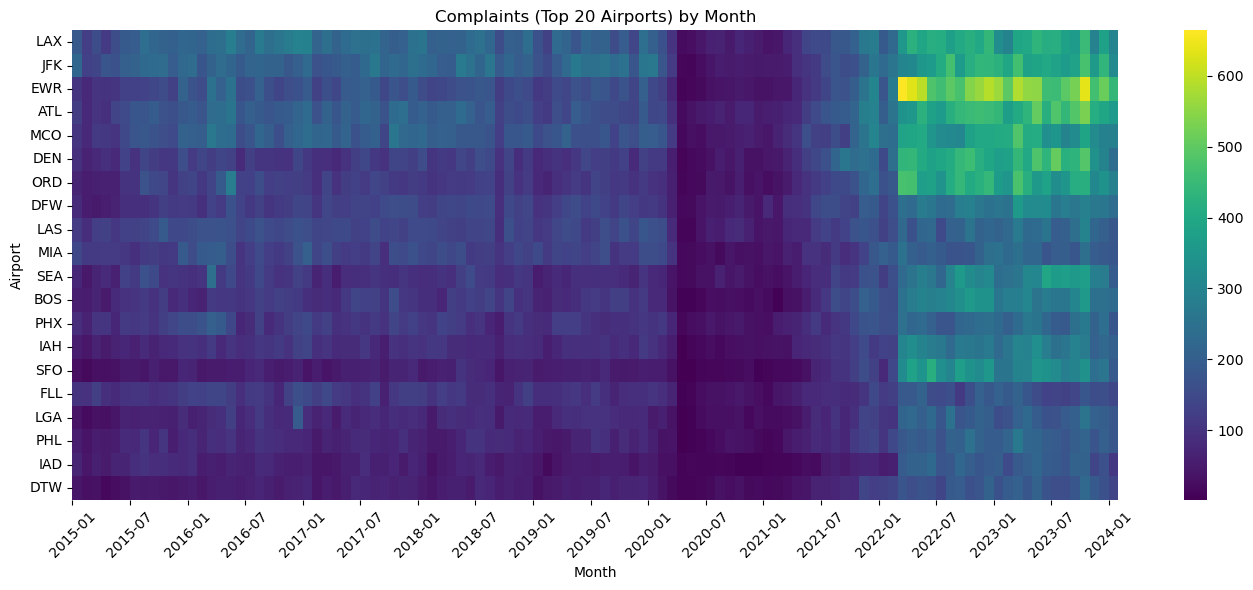

In [27]:
top_airports = airport_totals.head(20)['airport'].tolist()

data = (
    airport[airport['airport'].isin(top_airports)]
    .pivot_table(index='airport', columns='year_month', values='count', aggfunc='sum', fill_value=0)
    .loc[top_airports]
)

plt.figure(figsize=(14, 6))
sb.heatmap(data, cmap='viridis')
plt.title('Complaints (Top 20 Airports) by Month')
plt.xlabel('Month')
plt.ylabel('Airport')

plt.xticks(
    ticks=range(0, data.shape[1], 6),
    labels=[data.columns[i].strftime('%Y-%m') for i in range(0, data.shape[1], 6)],
    rotation=45
)

plt.tight_layout()
plt.show()

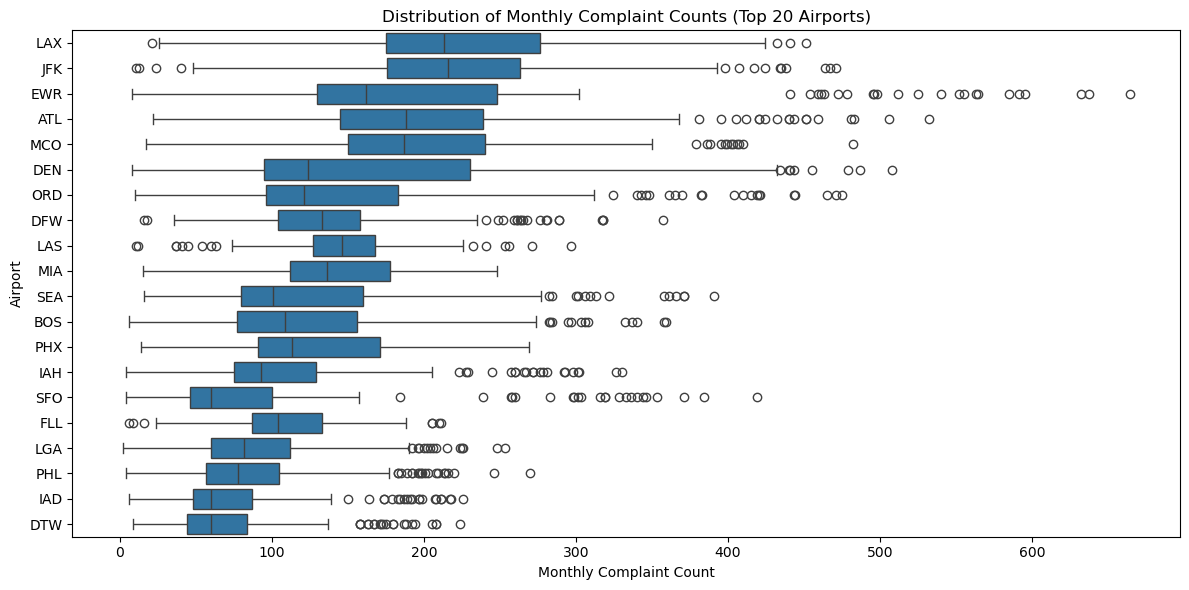

In [28]:
data = airport[airport['airport'].isin(top_airports)]

plt.figure(figsize=(12,6))
sb.boxplot(data=data, y='airport', x='count', order=top_airports, orient='h', showfliers=True)

plt.title('Distribution of Monthly Complaint Counts (Top 20 Airports)')
plt.xlabel('Monthly Complaint Count')
plt.ylabel('Airport')
plt.tight_layout()
plt.show()

In [29]:
map_data = airport_geo.dropna(subset=['latitude','longitude']).copy()

# normalize (0 to 1) then scale (* 100) and set min size (+ 10)
map_data['size'] = (map_data['count'] - map_data['count'].min()) / (map_data['count'].max() - map_data['count'].min()) * 100 + 10

fig = px.scatter_geo(map_data, lat='latitude', lon='longitude', hover_name='airport_x', size='size', projection='natural earth', title='Geographic Distribution of Complaints')
fig.update_layout(height=600)
fig.show()

## Project Overview

### Audience

The intended audience for this analysis is TSA management and airport operations leadership, who can use insights on trends and patterns in airport complaints to help with decision making. The audience may be too technical on the subject but the visualizations are designed to be clearand easy to interpret so that even those outside the intended audience can easily understand the key findings.

### Purpose

The purpose of this analysis is to analyze the data to identify any trends and/or patterns of airport complaints and their categories. The goal is to provide information on what part of airport operations need attention along with the airport at which they often occur. The call to action is for TSA and airport operations to improve their passenger experience, address the most frequent and severe complaint categories, and allocate resources to airports with the highest complaint volumes.

### Medium

The medium for this analysis is various graphs and charts made with python using the 3 TSA complaint datasets and the IATA/ICAO dataset for airport codes and location coordinates.

### Design

The visualizations were made to be easy to understand while still providing useful information related to the purpose and call to action of the analysis. They highlight trends over time, differences across airports, and the distribution of complaints by category and subcategory, allowing management to quickly identify areas that need attention and make decisions to improve passenger experience and operational efficiency. The spatial visualization acts as a bubble chart and is also interactive, allowing users to zoom in and out to explore specific regions and airports in greater detail.

### Ethical Considerations

The main changes to the data were cleaning up invalid airport code, standarizing capitalization and removing whitespaces for airport codes, and formatting date columns into datetime formats. Some of this data was also aggregated to get total counts of complaints based on airport, date, and complaint categories.

There are no regulatory or legal guidelines for the data as they're all publicly available datasets.

The aggregation and filtering of some of the data might make it seem like some airports have little to no issues due to how they compare to airports with higher numbers of complaints, however this is likely due to the size/popularity of some airports, such as LAX, versus a smaller, less visited airport that would naturally have less complaints.

I didn't really make any assumptions while working on this analysis, the datasets provided a lot of information, the only issue was cleaning up NaNs. All filtered data is clearly label as such in their visualizations, such as "Top 20".

The data comes from publicly available data sources, mainly from the TSA, which means the data is likely credible.

My data was acquired ethically, as it's all publicly available data from a government agency.

My only implication was how smaller airports might seem like they have little to no issues, however if they're in the data they have complaints which means there is things that need work. Lower complaint numbers are likely due to smaller airport sizes not perfect service.